# Legends

Heatmaps and simple annotations automatically generate legends placed on the right side of the heatmap. Complex annotations do not produce legends by default, but they can be constructed manually.

All legends are internally constructed by the `Legend()` constructor and belong to the `Legends` class. This tutorial covers discrete legends, continuous legends, customization, multi-column layout, `pack_legend`, and legend position.

In [1]:
import numpy as np
import complexheatmap as ch
from complexheatmap import (
    Heatmap, HeatmapAnnotation, Legend, Legends, pack_legend, color_ramp2
)
import grid_py as gp

## Continuous Legend

A continuous legend requires a color mapping function from `color_ramp2`. The break values in the function are used to determine legend ticks.

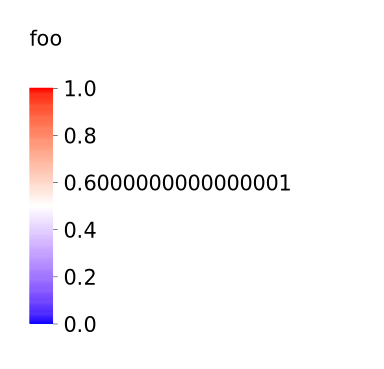

In [2]:
col_fun = color_ramp2([0, 0.5, 1], ["blue", "white", "red"])

lgd = Legend(col_fun=col_fun, title="foo")
lgd

### Custom break values

Use `at` to manually set the break values displayed in the legend.

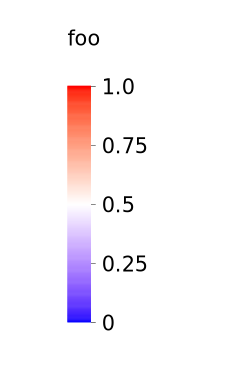

In [3]:
lgd = Legend(col_fun=col_fun, title="foo",
            at=[0, 0.25, 0.5, 0.75, 1.0])
lgd

### Custom labels

The `labels` argument provides human-readable labels at the break positions.

In [4]:
lgd = Legend(col_fun=col_fun, title="foo",
            at=[0, 0.5, 1],
            labels=["low", "median", "high"])

## Discrete Legend

A discrete legend maps categorical levels to colors. Provide `at` (the levels) and `labels`.

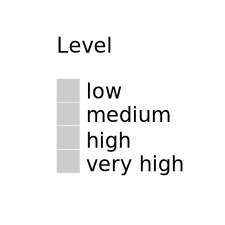

In [5]:
lgd = Legend(
    at=[1, 2, 3, 4],
    labels=["low", "medium", "high", "very high"],
    title="Level"
)
lgd

## Legend with Custom Graphic Parameters

The `legend_gp` argument controls the fill colors (and other graphic parameters) for discrete legends. `grid_height` and `grid_width` control the size of each legend entry.

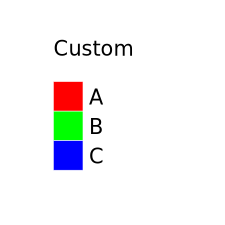

In [6]:
lgd_custom = Legend(
    at=[1, 2, 3],
    labels=["A", "B", "C"],
    title="Custom",
    legend_gp={"fill": ["red", "green", "blue"]},
    grid_height=5.0,
    grid_width=5.0
)
lgd_custom

## Multi-column Legend

When there are many levels, the `ncol` argument arranges legend entries in multiple columns.

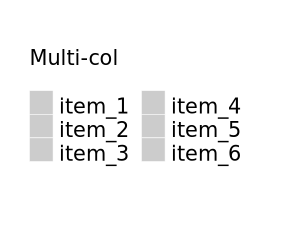

In [7]:
lgd_ncol = Legend(
    at=list(range(1, 7)),
    labels=[f"item_{i}" for i in range(1, 7)],
    title="Multi-col",
    ncol=2
)
lgd_ncol

## `pack_legend`: Combining Multiple Legends

`pack_legend` merges multiple legend objects into one. The `direction` argument controls vertical or horizontal layout.

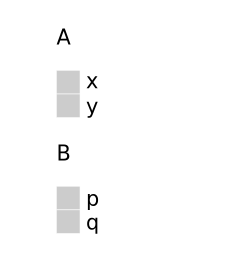

In [8]:
lgd_a = Legend(at=[1, 2], labels=["x", "y"], title="A")
lgd_b = Legend(at=[3, 4], labels=["p", "q"], title="B")

packed = pack_legend(lgd_a, lgd_b)
packed

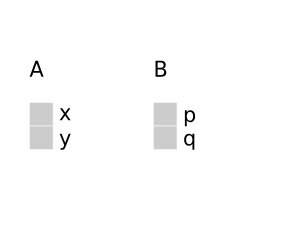

In [9]:
# Horizontal packing
packed_h = pack_legend(lgd_a, lgd_b, direction="horizontal")
packed_h

## Title Position

The `title_position` argument controls where the legend title is placed relative to the legend body. Options include `"topleft"`, `"topcenter"`, `"leftcenter"`, `"lefttop"`, etc.

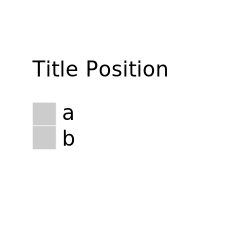

In [10]:
lgd = Legend(
    at=[1, 2],
    labels=["a", "b"],
    title="Title Position",
    title_position="topleft"
)
lgd

## Legends in Heatmaps

In practice, you typically configure legends through `heatmap_legend_param` in `Heatmap()` or `annotation_legend_param` in `HeatmapAnnotation()`. Most parameters from `Legend()` can be used directly.

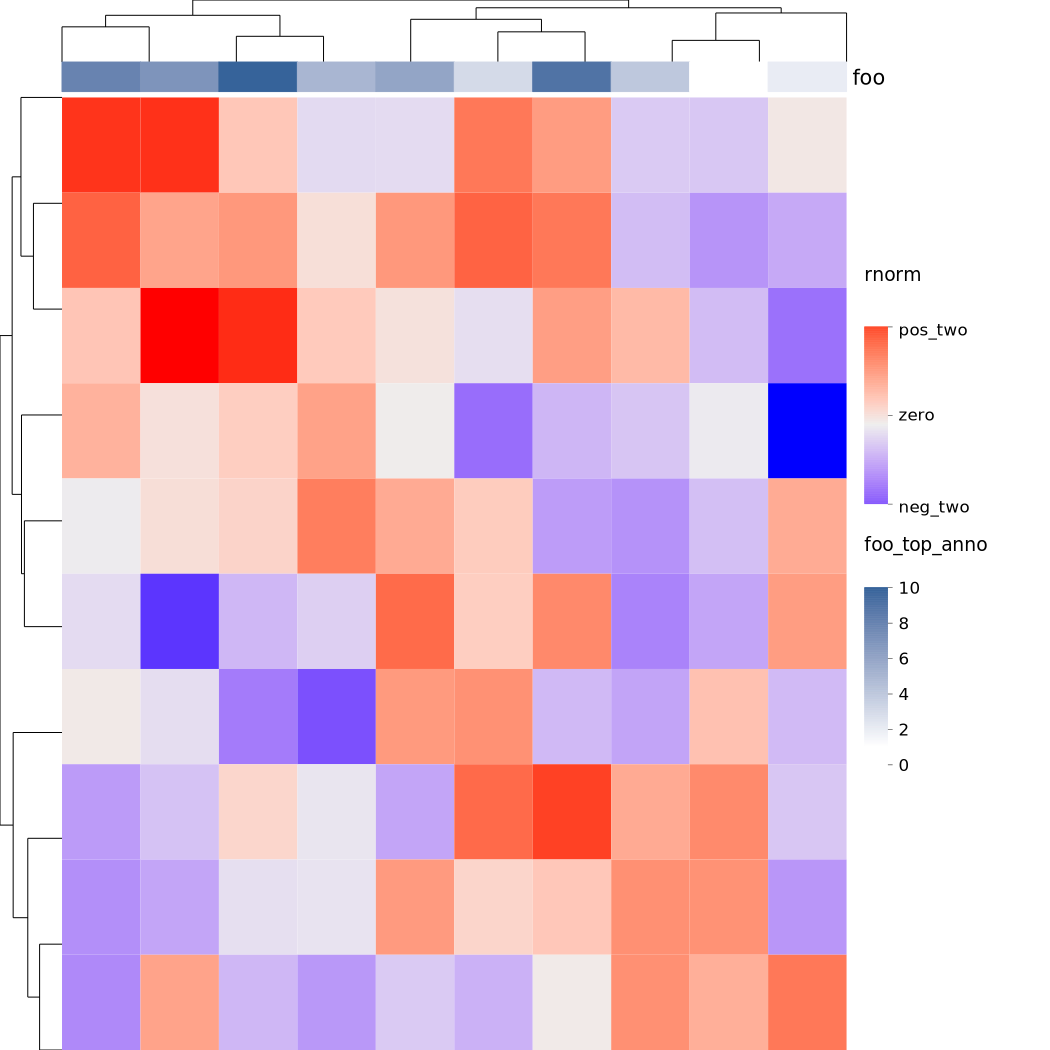

In [11]:
np.random.seed(123)
mat = np.random.randn(10, 10)

ht = Heatmap(mat, name="rnorm",
    heatmap_legend_param={
        "title": "rnorm",
        "at": [-2, 0, 2],
        "labels": ["neg_two", "zero", "pos_two"]
    },
    top_annotation=HeatmapAnnotation(
        foo=np.arange(1, 11),
        annotation_legend_param={"foo": {"title": "foo_top_anno"}}
    )
)
ht.draw()

## Legend Position

The `heatmap_legend_side` argument in `draw()` controls the position of the legend. Options are `"right"` (default), `"left"`, `"top"`, `"bottom"`.

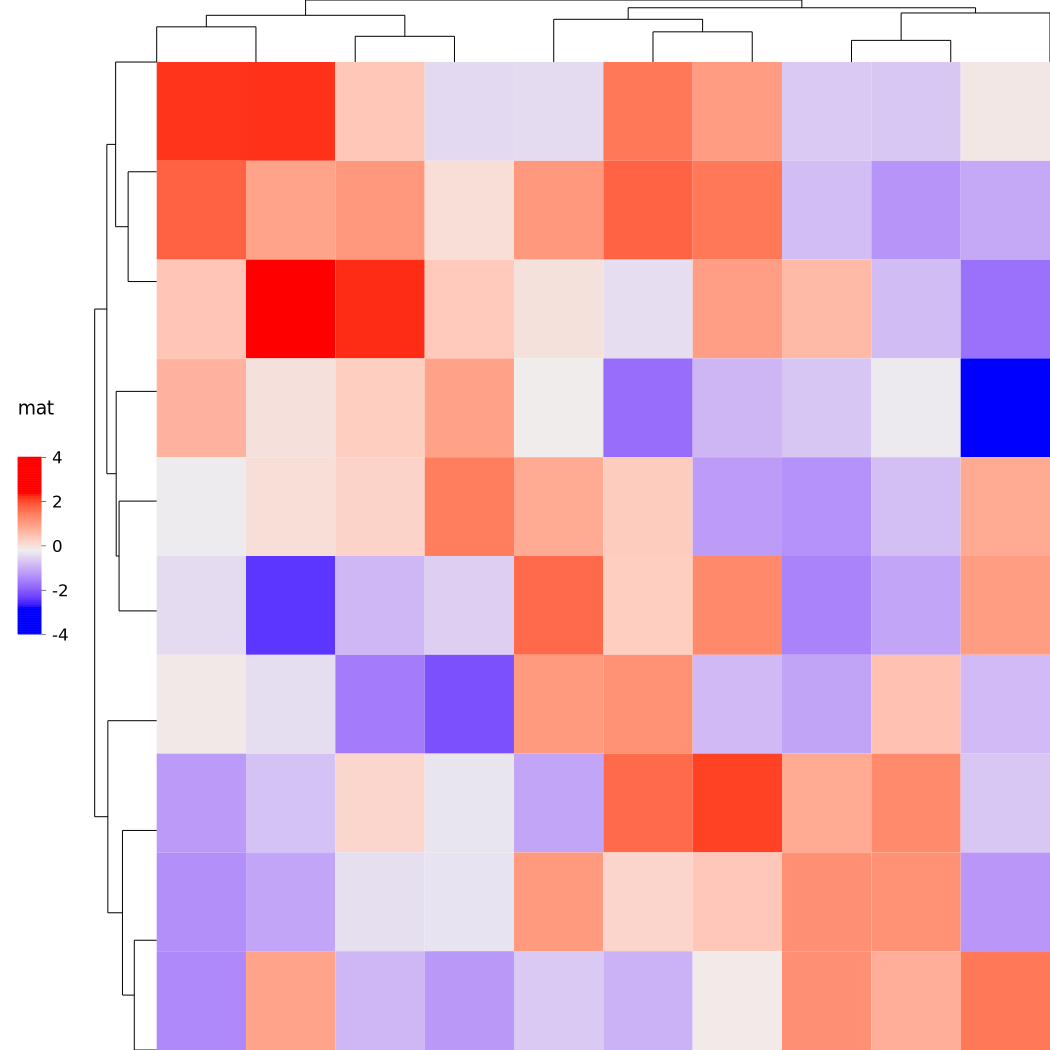

In [12]:
ht = Heatmap(mat, name="mat")
ht.draw(heatmap_legend_side="left")

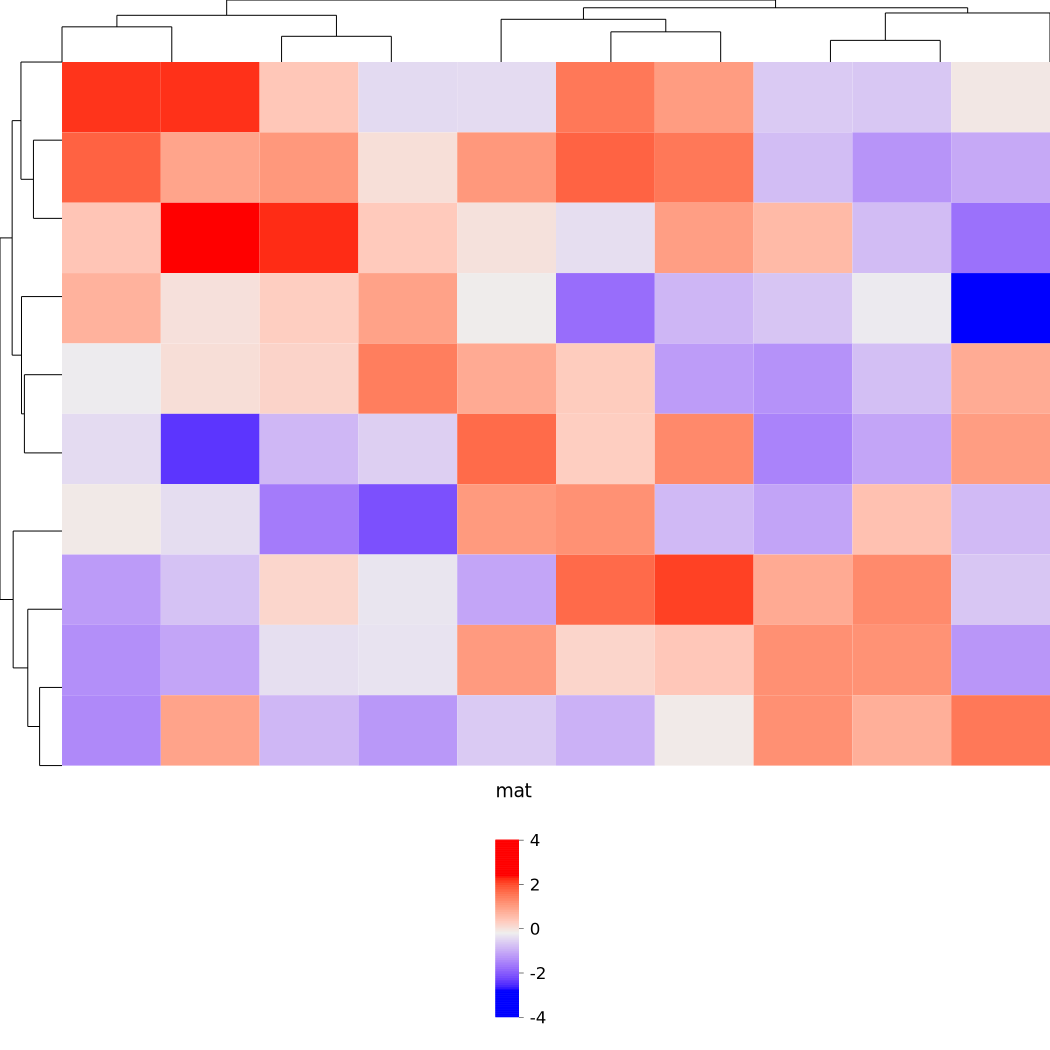

In [13]:
ht.draw(heatmap_legend_side="bottom")

## Adding Custom Legends

For complex annotations that do not auto-generate legends, build `Legend` objects manually and pass them through `annotation_legend_list` in `draw()`.

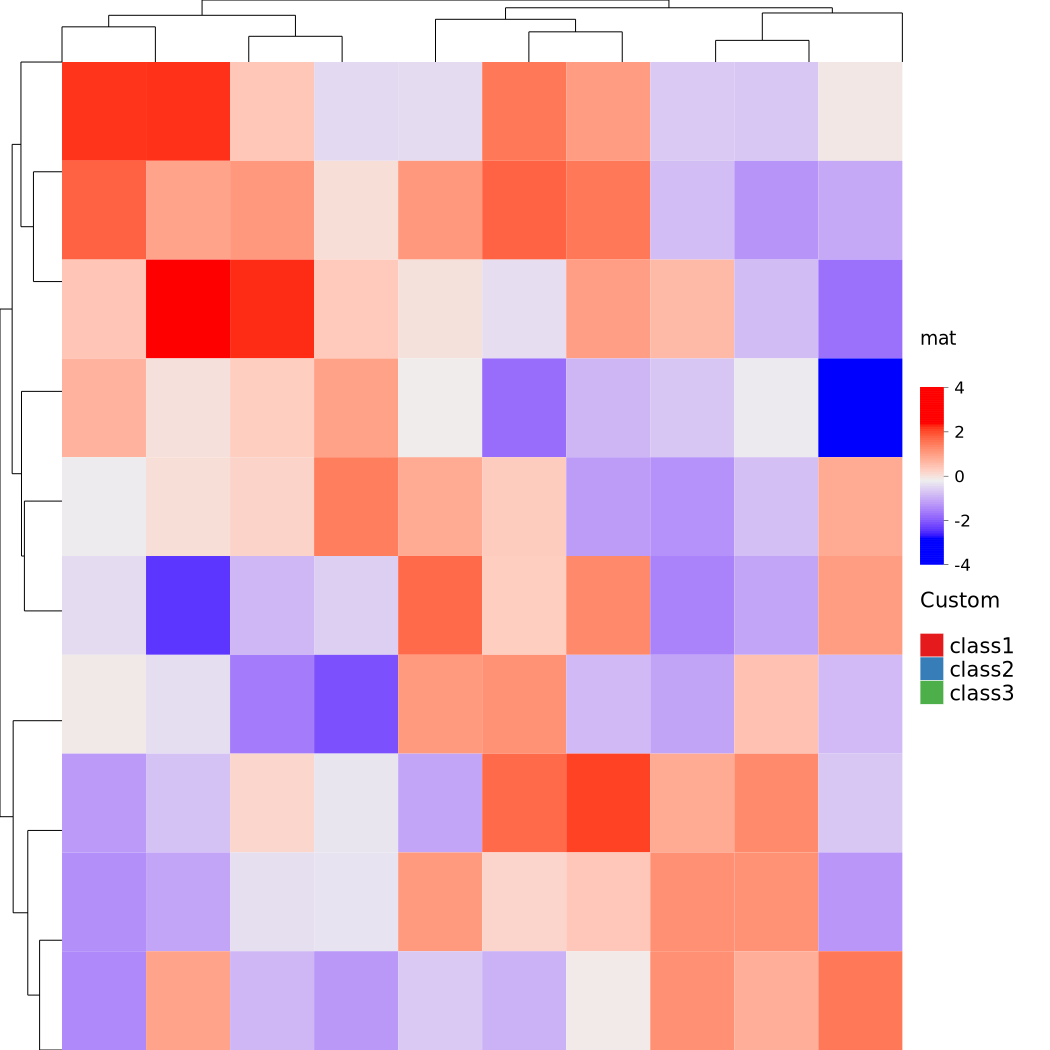

In [14]:
# Create a heatmap with a custom extra legend
ht = Heatmap(mat, name="mat")

lgd_extra = Legend(
    at=[1, 2, 3],
    labels=["class1", "class2", "class3"],
    title="Custom",
    legend_gp={"fill": ["#E41A1C", "#377EB8", "#4DAF4A"]}
)

ht.draw(        annotation_legend_list=[lgd_extra])

## Summary

This tutorial covered:

- Continuous legends from `color_ramp2` color functions
- Discrete legends with `at` and `labels`
- Custom graphic parameters via `legend_gp`, `grid_width`, `grid_height`
- Multi-column legends via `ncol`
- Combining legends with `pack_legend` (vertical and horizontal)
- Title positioning with `title_position`
- In-heatmap legend configuration via `heatmap_legend_param` and `annotation_legend_param`
- Legend placement with `heatmap_legend_side`
- Adding custom legends with `annotation_legend_list`